In [678]:
import pandas as pd

In [679]:
df = pd.read_csv(r"dataset\BBC News Train.csv")
print(f'''
      Shape: {df.shape}
      Columns: {df.columns.tolist()}
      Category column values: {df['Category'].unique().tolist()}
''')


      Shape: (1490, 3)
      Columns: ['ArticleId', 'Text', 'Category']
      Category column values: ['business', 'tech', 'politics', 'sport', 'entertainment']



## Data filtering

In [680]:
tech_data = df[df.Category=='tech']
print(tech_data.shape)
tech_data.head()

(261, 3)


,ArticleId,Text,Category
3,1976,lifestyle governs mobile choice faster bett...,tech
19,1552,moving mobile improves golf swing a mobile pho...,tech
24,405,bt boosts its broadband packages british telec...,tech
26,702,peer-to-peer nets here to stay peer-to-peer ...,tech
30,1951,pompeii gets digital make-over the old-fashion...,tech


In [681]:
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [682]:
tech_data = tech_data.copy()

tech_data["num_sent"] = tech_data["Text"].apply(lambda x: len(sent_tokenize(x)))
filtered_data = tech_data[tech_data['Text'].str.contains('game',case=False,na=False)]

filtered_data = filtered_data.copy()
filtered_data = filtered_data[(filtered_data["num_sent"] <= 15)]
filtered_data = filtered_data.drop_duplicates(subset=['Text'], keep='first')

filtered_data.to_csv(r'filtered_data.csv',index=False)

In [683]:
print(filtered_data.shape)
filtered_data.sort_values('num_sent')

(15, 4)


,ArticleId,Text,Category,num_sent
854,1179,bbc web search aids odd queries the bbc s onli...,tech,6
686,37,gamers snap up new sony psp gamers have bought...,tech,8
301,428,microsoft takes on desktop search microsoft ha...,tech,10
581,1606,sony psp console hits us in march us gamers wi...,tech,10
91,1756,2d metal slug offers retro fun like some drill...,tech,13
459,1383,more movies head to sony s psp movies open wat...,tech,13
977,475,nintendo adds media playing to ds nintendo is ...,tech,13
19,1552,moving mobile improves golf swing a mobile pho...,tech,14
48,277,halo 2 sells five million copies microsoft is ...,tech,14
397,254,first look at playstation 3 chip some details ...,tech,14


## Sentence Spliting

In [684]:
sentences = []
source_ids = []

for idx, row in filtered_data.iterrows():
    article_id = row["ArticleId"]
    text = row["Text"]
    
    sents = sent_tokenize(text)
    
    for s in sents:
        s = s.strip()
        if len(s) > 0:
            sentences.append(s)
            source_ids.append(article_id)

In [685]:
sent_df = pd.DataFrame({
    "article_id": source_ids,
    "sentence": sentences
})

In [686]:
print(sent_df.shape)
sent_df.head(20)

(189, 2)


,article_id,sentence
0,1552,moving mobile improves golf swing a mobile pho...
1,1552,the motion-sensitive phone - officially titled...
2,1552,devised mainly for mobile gaming users can al...
3,1552,the phone will allow golf fans to improve thei...
4,1552,those who prefer shoot- em-ups will be able to...
5,1552,the phone comes with a tiny motion-control sen...
6,1552,other features include a display screen that a...
7,1552,it also doubles up as an electronic musical in...
8,1552,users have to select a sound from a menu that ...
9,1552,it is being recommended for the karaoke market.


## Sentence preprocessing

In [687]:
import re
import unicodedata

In [688]:
clean_sentences = []
kept_source_ids = []

for idx, row in sent_df.iterrows():
    s = row['sentence']
    
    if not isinstance(s, str):
        continue
    
    s = s.strip()
    
    if len(s.split()) < 5:
        continue
    
    if not re.search(r"[A-Za-z]", s):
        continue
    
    if len(re.sub(r"[A-Za-z0-9]", "", s)) / max(1, len(s)) > 0.5:
        continue
    
    bad_patterns = [
        r"click here", r"share this", r"subscribe", r"read more",
        r"copyright", r"all rights reserved"
    ]
    if any(re.search(pat, s.lower()) for pat in bad_patterns):
        continue
    
    clean_sentences.append(s)
    kept_source_ids.append(row['article_id'])

In [689]:
assert len(clean_sentences) == len(kept_source_ids)

In [690]:
filtered_sent_df = pd.DataFrame({
    "article_id": kept_source_ids,
    "sentence": clean_sentences
    })

print("Before:", sent_df.shape)
print("After:", filtered_sent_df.shape)

Before: (189, 2)
After: (185, 2)


In [691]:
filtered_sent_df.head()

,article_id,sentence
0,1552,moving mobile improves golf swing a mobile pho...
1,1552,the motion-sensitive phone - officially titled...
2,1552,devised mainly for mobile gaming users can al...
3,1552,the phone will allow golf fans to improve thei...
4,1552,those who prefer shoot- em-ups will be able to...


In [692]:
def light_clean(text):
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[-_]{2,}', ' ', text)
    text = re.sub(r'([!?.,]){2,}', r'\1', text)
    text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != "C")
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    
    return text

In [693]:
df_sent = filtered_sent_df.copy()

df_sent["clean_sentence"] = df_sent["sentence"].astype(str).apply(light_clean)

In [694]:
before = df_sent.shape[0]
df_sent = df_sent[df_sent["clean_sentence"].str.strip() != ""].reset_index(drop=True)
after = df_sent.shape[0]

final_df = df_sent[["article_id", "clean_sentence"]].rename(columns={"clean_sentence": "sentence"})

In [695]:
print(f"Sentences before cleaning: {before}")
print(f"Sentences after cleaning & removing empties: {after}")

Sentences before cleaning: 185
Sentences after cleaning & removing empties: 185


In [696]:
final_df.head()

,article_id,sentence
0,1552,moving mobile improves golf swing a mobile pho...
1,1552,the motion-sensitive phone - officially titled...
2,1552,devised mainly for mobile gaming users can als...
3,1552,the phone will allow golf fans to improve thei...
4,1552,those who prefer shoot- em-ups will be able to...


## Sentence Embedings

In [697]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [698]:
MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 64 

model = SentenceTransformer(MODEL_NAME)

In [699]:
sentences = final_df["sentence"].astype(str).tolist()
print("Number of sentences to encode:", len(sentences))

Number of sentences to encode: 185


In [700]:
embeddings = model.encode(sentences,
                batch_size=BATCH_SIZE,
                show_progress_bar=True,
                convert_to_numpy=True
            )

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embeddings shape: (185, 384)


In [701]:
sent_emb_df = final_df.reset_index(drop=True).copy()
sent_emb_df["emb_index"] = np.arange(len(sent_emb_df))

sent_emb_df.head()

,article_id,sentence,emb_index
0,1552,moving mobile improves golf swing a mobile pho...,0
1,1552,the motion-sensitive phone - officially titled...,1
2,1552,devised mainly for mobile gaming users can als...,2
3,1552,the phone will allow golf fans to improve thei...,3
4,1552,those who prefer shoot- em-ups will be able to...,4


## Dimensionality reduction

In [702]:
import umap

In [703]:
print("Original embedding shape:", embeddings.shape)

Original embedding shape: (185, 384)


In [704]:
n_components_cluster = 20   # You can adjust between 10 and 30
n_neighbors = 15            # Controls how local/global the structure is

In [705]:
umap_cluster = umap.UMAP(
    n_components=n_components_cluster,
    n_neighbors=n_neighbors,
    metric='cosine',
    random_state=42
)

emb_reduced = umap_cluster.fit_transform(embeddings)
print("Reduced embedding shape:", emb_reduced.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embedding shape: (185, 20)


In [706]:
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

emb_2d = umap_2d.fit_transform(embeddings)
print("2D embedding shape:", emb_2d.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embedding shape: (185, 2)


In [707]:
sent_emb_df["umap_x"] = emb_2d[:, 0]
sent_emb_df["umap_y"] = emb_2d[:, 1]

sent_emb_df.head()

,article_id,sentence,emb_index,umap_x,umap_y
0,1552,moving mobile improves golf swing a mobile pho...,0,12.710719,1.214358
1,1552,the motion-sensitive phone - officially titled...,1,12.696245,1.020348
2,1552,devised mainly for mobile gaming users can als...,2,12.465069,1.413312
3,1552,the phone will allow golf fans to improve thei...,3,12.671522,1.320490
4,1552,those who prefer shoot- em-ups will be able to...,4,12.308370,1.112140


## HDBSCAN Clustering

In [708]:
import hdbscan

In [709]:
MIN_CLUSTER_SIZE = 4    # minimum number of sentences to form a cluster (smaller -> more clusters)
MIN_SAMPLES = None      # None lets HDBSCAN choose; set integer for more conservative clusters
METRIC = "euclidean"    # emb_reduced from UMAP is Euclidean-friendly

In [710]:

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric=METRIC,
    cluster_selection_method="eom",
    prediction_data=True,
    core_dist_n_jobs=4
)

In [711]:
labels = clusterer.fit_predict(emb_reduced)
probs = clusterer.probabilities_

sent_emb_df = sent_emb_df.copy().reset_index(drop=True)
sent_emb_df["hdb_cluster"] = labels
sent_emb_df["hdb_prob"] = probs

n_sentences = sent_emb_df.shape[0]
n_noise = int((sent_emb_df["hdb_cluster"] == -1).sum())
clusters_found = sorted([c for c in set(labels) if c != -1])
n_clusters = len(clusters_found)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [712]:
print(f"Total sentences clustered: {n_sentences}")
print(f"Noise sentences (label -1): {n_noise}")
print(f"Clusters found (excluding noise): {n_clusters}")
print("Cluster ids:", clusters_found)

print("\nCluster sizes (including noise -1):")
print(sent_emb_df["hdb_cluster"].value_counts().sort_index())

Total sentences clustered: 185
Noise sentences (label -1): 14
Clusters found (excluding noise): 10
Cluster ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Cluster sizes (including noise -1):
-1    14
 0    10
 1    11
 2    16
 3    15
 4    14
 5    12
 6    52
 7    26
 8     9
 9     6
Name: hdb_cluster, dtype: int64


In [713]:

# Optional: show top sentences per cluster by probability (quick sanity check)
print("\nTop representative sentences per cluster (highest membership probability):")
for c in clusters_found:
    subset = sent_emb_df[sent_emb_df["hdb_cluster"] == c].sort_values("hdb_prob", ascending=False).head(3)
    print(f"\nCluster {c} (n={len(subset)}):")
    for _, row in subset.iterrows():
        print(" -", row["sentence"][:200], " ... (prob:{:.2f})".format(row["hdb_prob"]))


Top representative sentences per cluster (highest membership probability):

Cluster 0 (n=3):
 - us peer-to-peer pirates convicted the first convictions for piracy over peer-to-peer networks have been handed down in the us.  ... (prob:1.00)
 - the two men faced charges following raids in august on suspected pirates by the fbi.  ... (prob:1.00)
 - the pair face jail terms of up to five years and a $250 000 (£130 000) fine.  ... (prob:1.00)

Cluster 1 (n=3):
 - the chip will be made of several different processing cores that work on tasks together.  ... (prob:1.00)
 - the three firms have been working on the chip since 2001 but before now few details have been released about how it might function.  ... (prob:1.00)
 - in a joint statement the three firms gave hints about how the chip will work but fuller details will be released in february next year at the international solid state circuits conference in san franc  ... (prob:1.00)

Cluster 2 (n=3):
 - microsoft takes on desktop search mi

In [714]:
sent_emb_df.to_csv(r"dataset\output\sentences_with_hdbscan_clusters.csv", index=False)

## Keywords for each cluster

In [715]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [716]:
TOP_N_KEYWORDS = 10
TOP_N_REP_SENTENCES = 5
CONFIDENCE_THRESHOLD = 0.60

In [717]:
df = sent_emb_df.copy().reset_index(drop=True)

vectorizer = TfidfVectorizer(stop_words="english", max_features=8000, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(df["sentence"].astype(str))
terms = np.array(vectorizer.get_feature_names_out())

clusters = sorted([c for c in df["hdb_cluster"].unique() if c != -1])

In [718]:
cluster_summaries = []

print("Found clusters (excluding noise):", clusters)
for c in clusters:
    high_conf_idx = df[(df["hdb_cluster"] == c) & (df["hdb_prob"] >= CONFIDENCE_THRESHOLD)].index.to_numpy()
    if high_conf_idx.size == 0:
        idxs = df[df["hdb_cluster"] == c].index.to_numpy()
    else:
        idxs = high_conf_idx

    cluster_tfidf_sum = X_tfidf[idxs].sum(axis=0).A1
    top_term_indices = cluster_tfidf_sum.argsort()[::-1][:TOP_N_KEYWORDS]
    top_keywords = terms[top_term_indices].tolist()

    cluster_emb_idxs = df[df["hdb_cluster"] == c].index.to_numpy()
    cluster_embs = emb_reduced[cluster_emb_idxs]
    if cluster_embs.shape[0] == 0:
        rep_sentences = []
    else:
        centroid = cluster_embs.mean(axis=0, keepdims=True)
        sims = cosine_similarity(cluster_embs, centroid).reshape(-1)
        top_local = sims.argsort()[::-1][:TOP_N_REP_SENTENCES]
        top_global_idxs = cluster_emb_idxs[top_local]
        rep_sentences = df.loc[top_global_idxs, ["sentence", "hdb_prob", "article_id"]].to_dict(orient="records")

    summary = {
        "cluster_id": c,
        "n_sentences": int((df["hdb_cluster"] == c).sum()),
        "top_keywords": top_keywords,
        "representative_sentences": rep_sentences
    }
    cluster_summaries.append(summary)

    print("\n=== Cluster", c, f"(n={summary['n_sentences']}) ===")
    print("Top keywords:", ", ".join(top_keywords[:10]))
    print("Representative sentences:")
    for rep in rep_sentences:
        prob = rep.get("hdb_prob", None)
        aid = rep.get("article_id", None)
        sent_preview = rep["sentence"]
        print(f" - (prob={prob:.2f}, article_id={aid}) {sent_preview}")

Found clusters (excluding noise): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

=== Cluster 0 (n=10) ===
Top keywords: peer, men, piracy, peer peer, pirates, fbi, men sentenced, 29 april, 29, sentenced
Representative sentences:
 - (prob=1.00, article_id=372) us peer-to-peer pirates convicted the first convictions for piracy over peer-to-peer networks have been handed down in the us.
 - (prob=0.92, article_id=372) in a statement the us department of justice said the two men operated the central hubs in a piracy community organised across the direct connect peer-to-peer network.
 - (prob=1.00, article_id=372) the two men are due to be sentenced on 29 april.
 - (prob=0.99, article_id=372) the piracy group called itself the underground network and membership of it demanded that users share between one and 100 gigabytes of files.
 - (prob=1.00, article_id=372) the two men faced charges following raids in august on suspected pirates by the fbi.

=== Cluster 1 (n=11) ===
Top keywords: chip, cell, firms, re

In [719]:
summary_rows = []
for s in cluster_summaries:
    summary_rows.append({
        "cluster_id": s["cluster_id"],
        "n_sentences": s["n_sentences"],
        "top_keywords": "; ".join(s["top_keywords"]),
        "representative_sentences": " || ".join([f"(p={r['hdb_prob']:.2f},aid={r['article_id']}) {r['sentence']}" for r in s["representative_sentences"]])
    })


In [720]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(r"dataset\output\cluster_summaries.csv", index=False)

## Cluster visualization

In [721]:
import matplotlib.pyplot as plt

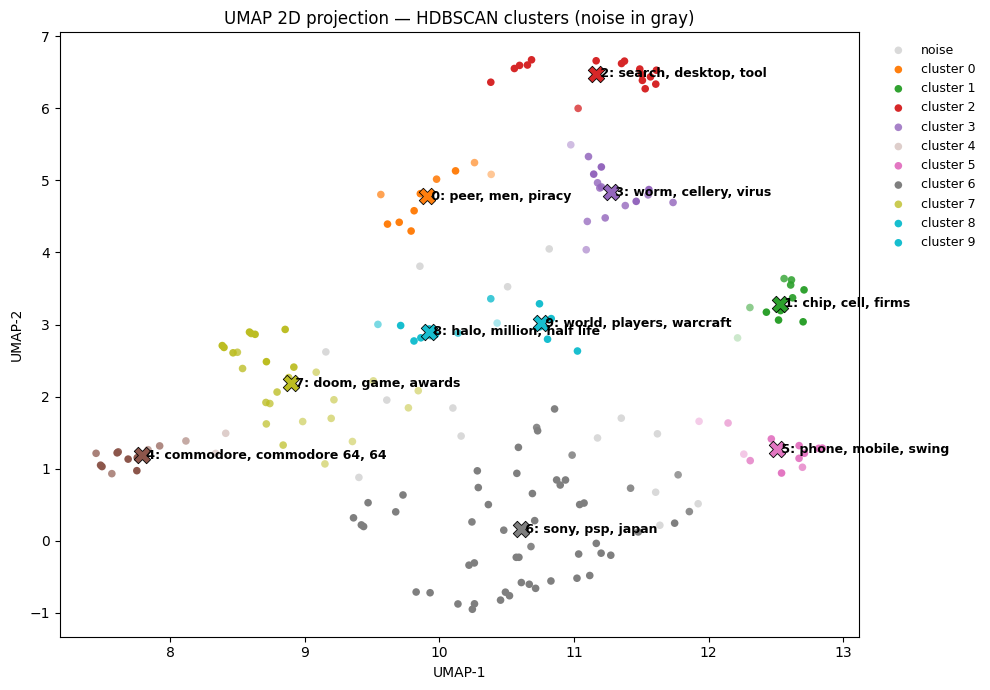

In [722]:
plt.rcParams["figure.dpi"] = 120
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 7))

df = sent_emb_df.copy().reset_index(drop=True)
xs = df["umap_x"].values
ys = df["umap_y"].values
labels = df["hdb_cluster"].values
probs = df["hdb_prob"].values

# Determine unique clusters and colors
unique_clusters = sorted(df["hdb_cluster"].unique())
# assign gray for noise (-1)
palette = plt.get_cmap("tab10")
cluster_colors = {c: (0,0,0) if c == -1 else palette(i % 50) for i, c in enumerate(unique_clusters)}

alphas = np.clip((probs - 0.2) / 0.8, 0.15, 1.0)
for c in unique_clusters:
    mask = (labels == c)
    ax.scatter(xs[mask], ys[mask],
               s=30,
               alpha=alphas[mask],
               color=cluster_colors[c],
               label=("noise" if c == -1 else f"cluster {c}"),
               linewidths=0.2,
               edgecolors="none")

non_noise = [c for c in unique_clusters if c != -1]
centroids = {}
for c in non_noise:
    mask = (labels == c)
    if mask.sum() == 0:
        continue
    cx = xs[mask].mean()
    cy = ys[mask].mean()
    centroids[c] = (cx, cy)
    ax.scatter(cx, cy, s=140, marker="X", color=cluster_colors[c], edgecolor="k", linewidth=0.6)

if 'summary_df' in globals():
    for _, row in summary_df.iterrows():
        cid = row['cluster_id']
        if cid in centroids:
            cx, cy = centroids[cid]
            kw = row['top_keywords'].split(';')[:3] if isinstance(row['top_keywords'], str) else []
            ax.text(cx, cy, f" {cid}: " + ", ".join([k.strip() for k in kw]),
                    fontsize=9, fontweight='bold', verticalalignment='center')

ax.set_title("UMAP 2D projection — HDBSCAN clusters (noise in gray)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
